In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
protein_name = "trp_cage"

In [4]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from models.schnet import SchNet
from models.gcn import GCN
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

KB = 0.83144626181  # This is the Boltzmann constant conversed from J/K (Kg, m^2 / s^2 / K) to -> g/mol, angstroms, ps and K.
temp_data = 300  # Temperature in K
masses = 12.0  # Mass of carbon in g/mol
friction = 1.0  # Friction coefficient in ps^-1

def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str, true_rate=None
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="Train Loss")
    plt.plot(x_test, test_losses, label="Test Loss")
    if true_rate is not None:
        plt.axhline(true_rate, color="r", linestyle="--", label="True Rate (Counting MD Simulations)")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")

In [5]:
device = torch.device(torch.device("cuda:6"))

# Load the MD data

gen_mode = "om_interpolate" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = "test_md" # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

md_samples_path = os.path.join(eval_folder, f"sample-{gen_mode}-md.pt")
om_points_path = os.path.join(eval_folder, f"sample-{gen_mode}.pt")
md_samples = torch.load(md_samples_path)
om_points = torch.load(om_points_path)

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}.npy",
    )
)
tic_cluster_coords = np.load(cluster_centers_path)

iid_sample_path = Path(os.path.join(os.path.dirname(eval_folder), "main_eval_output_iid"))
# Get TICA
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=iid_sample_path,
    data_folder="/data/sanjeevr/Reference_MD_Sims",
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)
# assign TIC cluster centers to the reference samples
tic_cluster_assignments, transformed_samples = discretize_trajectory(
    md_samples, tic_evaluator, tic_cluster_coords
)

tic_cluster_assignments = torch.tensor(tic_cluster_assignments)


n_atoms = md_samples.shape[1]

transformed_samples.shape




/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:206: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


(160000, 2)

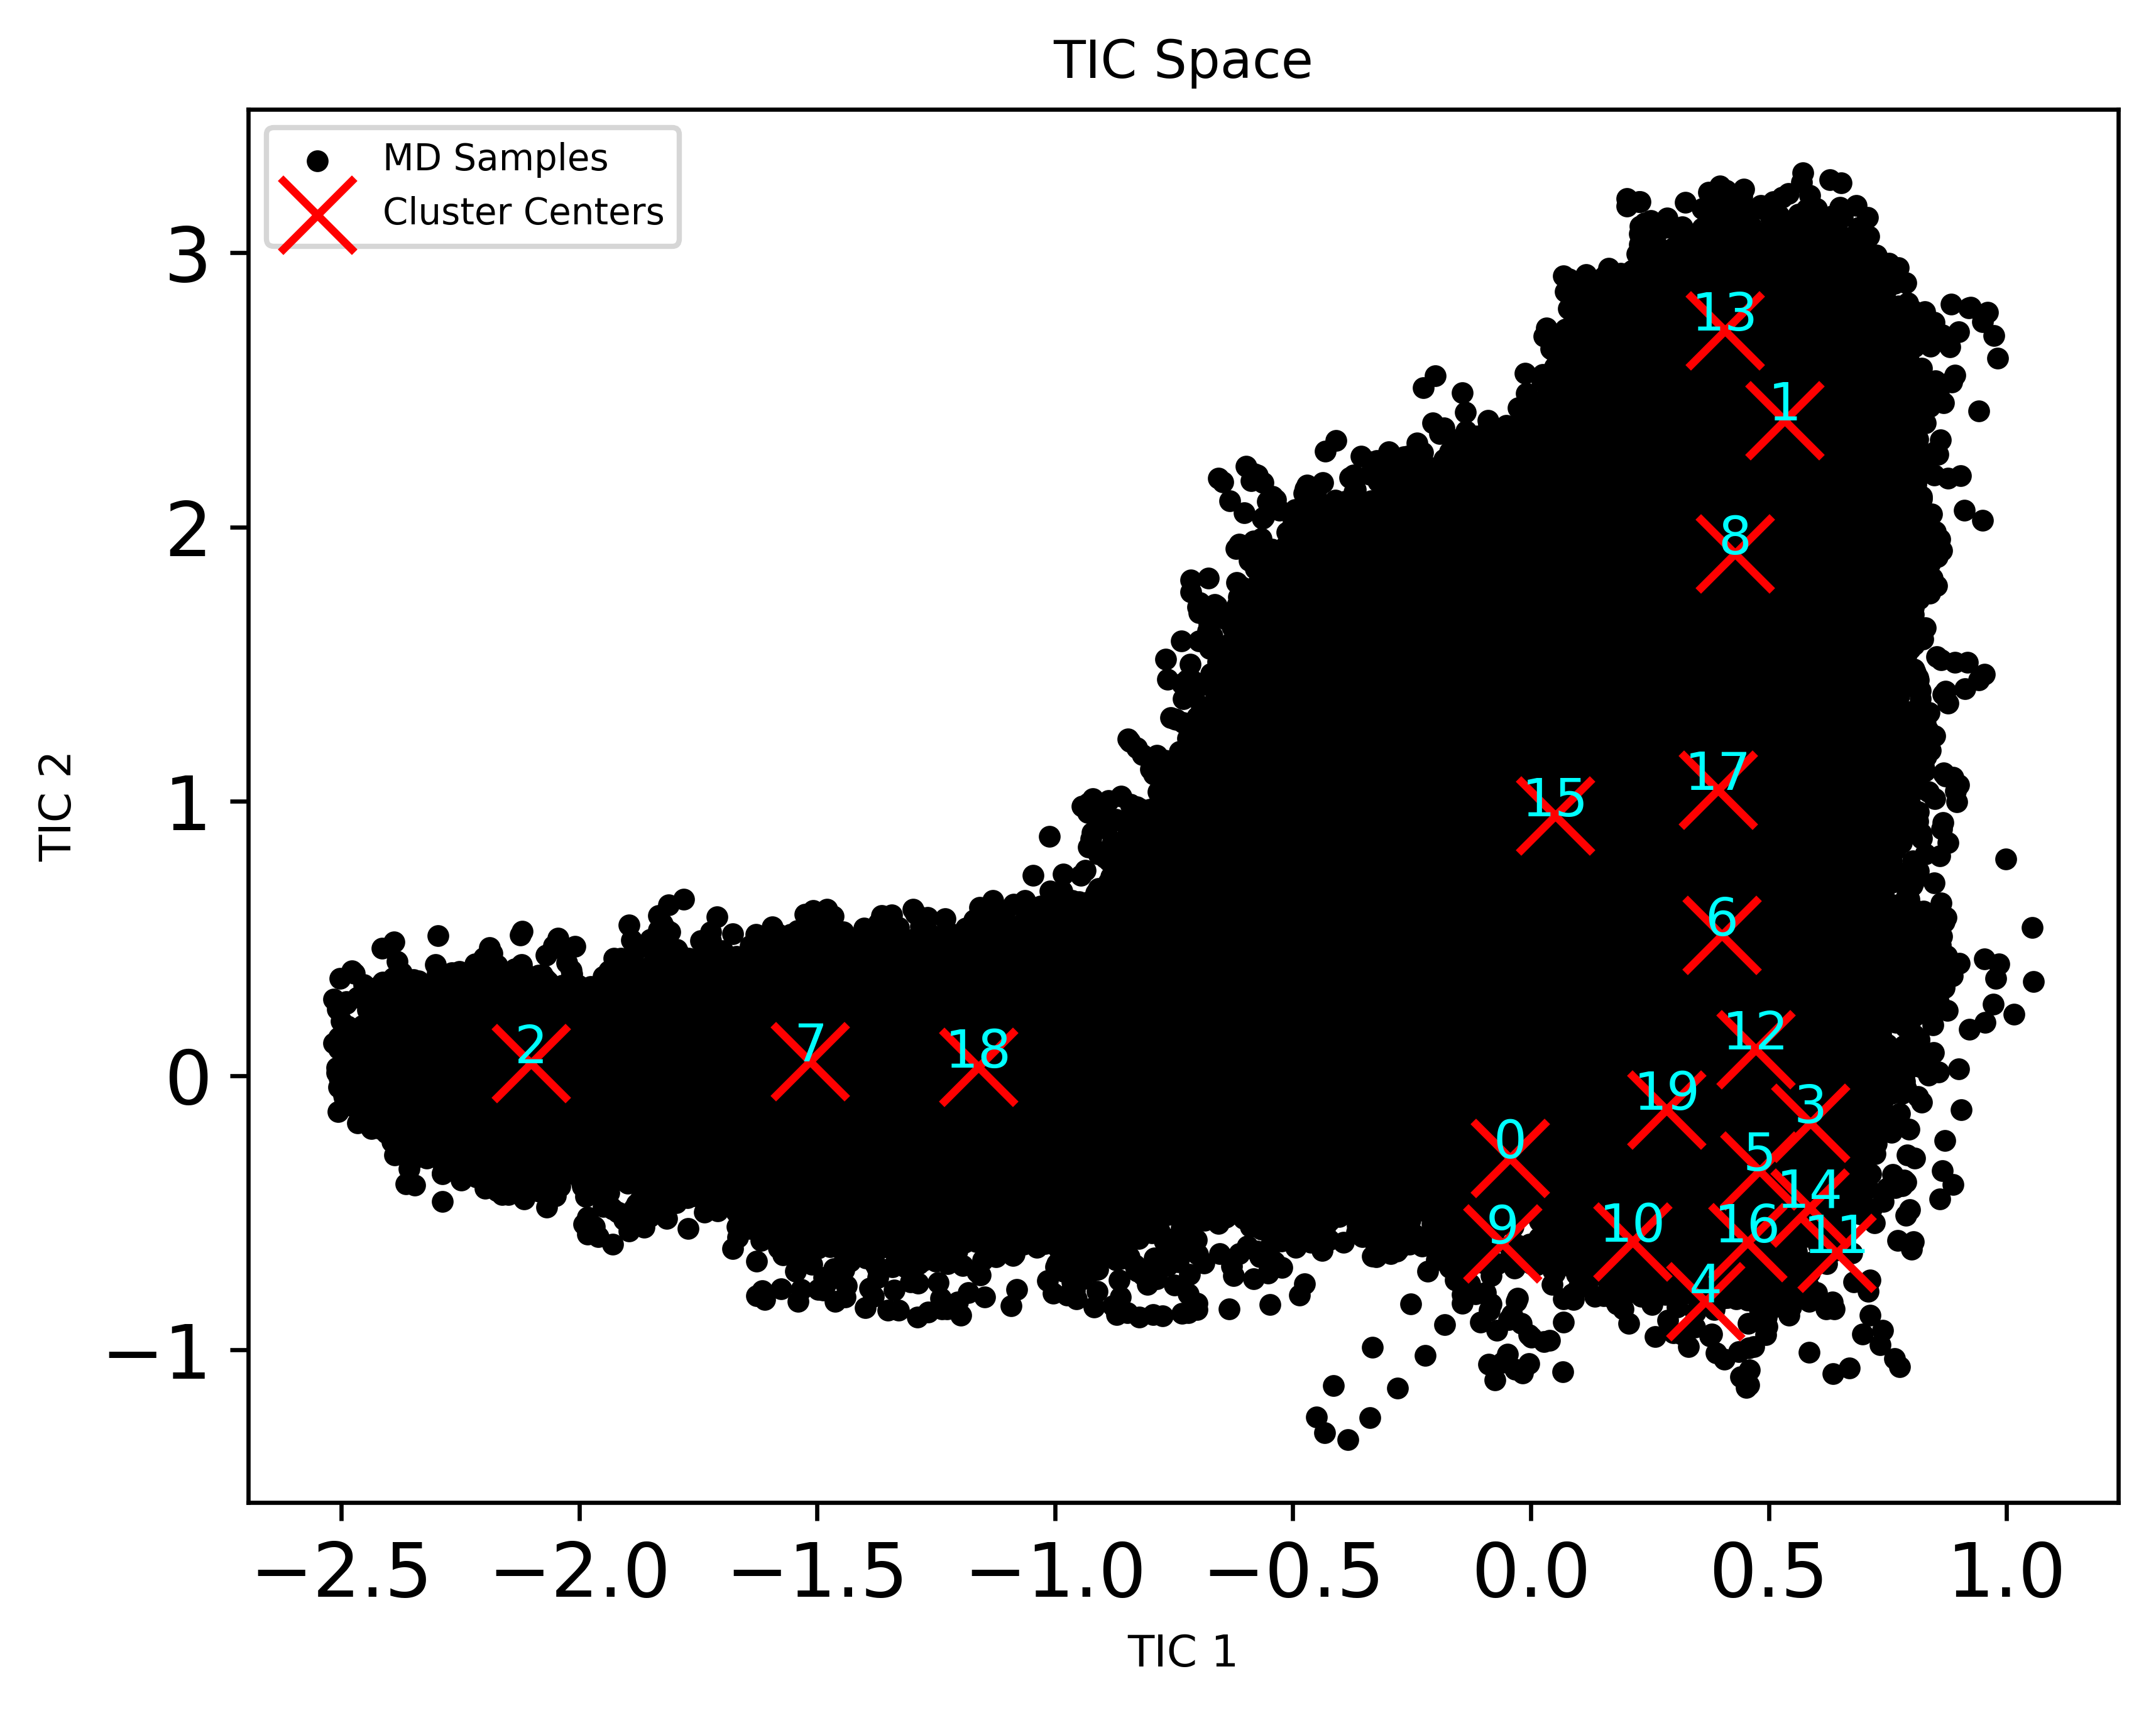

In [6]:
# Plot the TICA space with black points and red 'x' markers for cluster centers
plt.figure()
plt.scatter(transformed_samples[:, 0], transformed_samples[:, 1], c='black', s=10, label="MD Samples")
plt.scatter(tic_cluster_coords[:, 0], tic_cluster_coords[:, 1], c='red', s=200, marker='x', label='Cluster Centers')

# Add a text label above each cluster center with its index
for i, (x, y) in enumerate(tic_cluster_coords):
    plt.text(x, y, str(i), color='cyan', fontsize=10, ha='center')

# Set plot title and axis labels
plt.title("TIC Space")
plt.xlabel("TIC 1")
plt.ylabel("TIC 2")

# Show the plot
plt.legend()
plt.show()

In [20]:
# Digitize samples into bins
bins_x = np.digitize(transformed_samples[:, 0], tic_evaluator.bin_edges_x) - 1
bins_y = np.digitize(transformed_samples[:, 1], tic_evaluator.bin_edges_y) - 1

# Clip to ensure all indices are within bounds
bins_x = np.clip(bins_x, 0, tic_evaluator.bins - 1)
bins_y = np.clip(bins_y, 0, tic_evaluator.bins - 1)

gt_densities = tic_evaluator.gt_prob[bins_x, bins_y]
empirical_density, _, _ = np.histogram2d(
                transformed_samples[:, 0],
                transformed_samples[:, 1],
                bins=(tic_evaluator.bin_edges_x, tic_evaluator.bin_edges_y),
                density=True,
            )
empirical_density = empirical_density[bins_x, bins_y]
empirical_density += 1e-3*np.min(empirical_density[np.nonzero(empirical_density)])
reweighting_factors = torch.tensor(gt_densities / empirical_density)
# reweighting_factors = torch.ones_like(reweighting_factors)

In [11]:
# # compute assignments of trajectories to clusters defined by OM path waypoints
# def nullspace(A, atol=1e-13, rtol=0):
#     #Helper function to obtain null space
#     A = np.atleast_2d(A)
#     u, s, vh = np.linalg.svd(A)
#     tol = max(atol, rtol * s[0])
#     nnz = (s >= tol).sum()
#     ns = vh[nnz:].conj().T
#     ss = s[nnz:]
#     return ns, ss

# def compute_reweighting_factors(Kmatrix, tol=2e-9):
#     """Adapted from https://github.com/muhammadhasyim/tps-torch
#     Computes the reweighting factor z_l for each node point by solving an eigenvalue problem
        
#     Args:
#         Kmatrix (torch.Tensor): [n_path_points, n_path_points] tensor of transition rates between path points during MD simulation.
#         tol (float): Tolerance value for the off-diagonal elements of the Kmatrix. Default is 2e-9.
#     See Appendix A of paper 
#     https://pubs.aip.org/aip/jcp/article/157/18/184111/2842057/Supervised-learning-and-the-finite-temperature for more details.
#     """
    
#     N = Kmatrix.shape[0]
# 	#Add tolerance values to the off-diagonal elements
#     for i in range(N):
#         for j in range(N):
#             if abs(i-j) == 1:
#                 Kmatrix[i, j] += tol
        
#     #Build the final matrix
#     Kmatrix = Kmatrix.t()-torch.diag(torch.sum(Kmatrix,dim=1)-tol)
#     #Compute the reweighting factors using an eigensolver
#     v, w = nullspace(Kmatrix.numpy(), atol=tol)
#     try:
#         index = np.argmin(w)
#         zl = np.real(v[:,index])
#     except:
#         print("Failed")
#         #Shift value may not be small enough so we choose a default higher tolerance detection
#         v, w = nullspace(Kmatrix.numpy(), atol=10**(-5), rtol=0)
#         index = np.argmin(w)
#         zl = np.real(v[:,index])
    
#     #Normalize
#     zl /= np.sum(zl)  
#     return zl


# #Assign OM clusters to each frame based on distances to the OM optimized paths

# md_samples = md_samples.to(device)
# om_points = om_points.to(device)
# import pdb; pdb.set_trace()
# # TODO: kabsch align the every frame to the first OM point
# distances = torch.linalg.norm(md_samples.unsqueeze(1) - om_points.unsqueeze(0), dim=(-2, -1))
# om_cluster_assignments = torch.argmin(distances, dim=1)

# # Compute transition counts between OM clusters
# n_clusters = len(om_points)
# transition_counts = torch.zeros((n_clusters, n_clusters)).to(device)
# print("Computing transition rates between OM path waypoints")
# om_cluster_assignments = om_cluster_assignments.reshape(-1, 1000)
# for traj in tqdm(range(om_cluster_assignments.shape[0])):
#     for i in range(1, om_cluster_assignments.shape[1]):
#         transition_counts[om_cluster_assignments[traj, i-1], om_cluster_assignments[traj, i]] += 1

# # Remove clusters that have no population

# # Compute reweighting factors based on the OM cluster assignments 


In [13]:
def get_gt_committor_probs(tic_samples, start_cluster, end_cluster, clusters, tic):
    n_samples = tic_samples.shape[0]
    
    
    # Digitize samples into bins
    bins_x = np.digitize(tic_samples[:, 0], tic.bin_edges_x) - 1
    bins_y = np.digitize(tic_samples[:, 1], tic.bin_edges_y) - 1
    
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, tic.bins - 1)
    bins_y = np.clip(bins_y, 0, tic.bins - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * tic.bins + bins_y
    
    # Initialize committor probabilities tensor
    committor_probs = torch.zeros(tic.bins ** 2)
    bin_counts = torch.zeros(tic.bins ** 2)
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    for i in tqdm(range(n_samples)):
        bin_counts[bin_idx[i]] += 1
        if last_transition_idx is not None and i <= last_transition_idx:
            # If we already determined the committor for the intermediate steps, assign and skip
            committor_probs[bin_idx[i]] += last_committor
        else:
            if is_start[i]:
                committor_probs[bin_idx[i]] += 0
                last_committor = 0
                last_transition_idx = i
            elif is_end[i]:
                committor_probs[bin_idx[i]] += 1
                last_committor = 1
                last_transition_idx = i
            else:
                # Search forward in the trajectory to find the next transition
                subsequent_clusters = clusters[i:]
                first_start = np.argmax(subsequent_clusters == start_cluster)
                first_end = np.argmax(subsequent_clusters == end_cluster)

                if (first_end == 0 or first_start > 0 and first_start < first_end):
                    last_committor = 0
                    last_transition_idx = i + first_start
                elif (first_end > 0 and (first_start == 0 or first_end < first_start)):
                    last_committor = 1
                    last_transition_idx = i + first_end
                else:
                    raise RuntimeError(f"No transition found for sample {i}")
                
                # Assign committor for current step
                committor_probs[bin_idx[i]] += last_committor
    
    # Normalize committor probabilities by bin counts
    committor_probs = committor_probs / torch.clamp(bin_counts, min=1)
    
    # Save bin-wise committor probabilities
    
    return committor_probs[bin_idx]


start, end = CLUSTER_ENDPOINTS[protein_name]
probs = get_gt_committor_probs(transformed_samples, start, end, tic_cluster_assignments, tic_evaluator)
probs = torch.tensor(probs)


100%|██████████| 160000/160000 [00:02<00:00, 62264.86it/s]
/tmp/ipykernel_3698186/482437351.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  probs = torch.tensor(probs)


Epoch 1


100%|██████████| 110/110 [00:17<00:00,  6.32it/s]


Epoch 2


100%|██████████| 110/110 [00:17<00:00,  6.31it/s]


Epoch 3


...

100%|██████████| 110/110 [00:17<00:00,  6.25it/s]


Epoch 9


100%|██████████| 110/110 [00:17<00:00,  6.25it/s]


Epoch 10


100%|██████████| 110/110 [00:17<00:00,  6.25it/s]


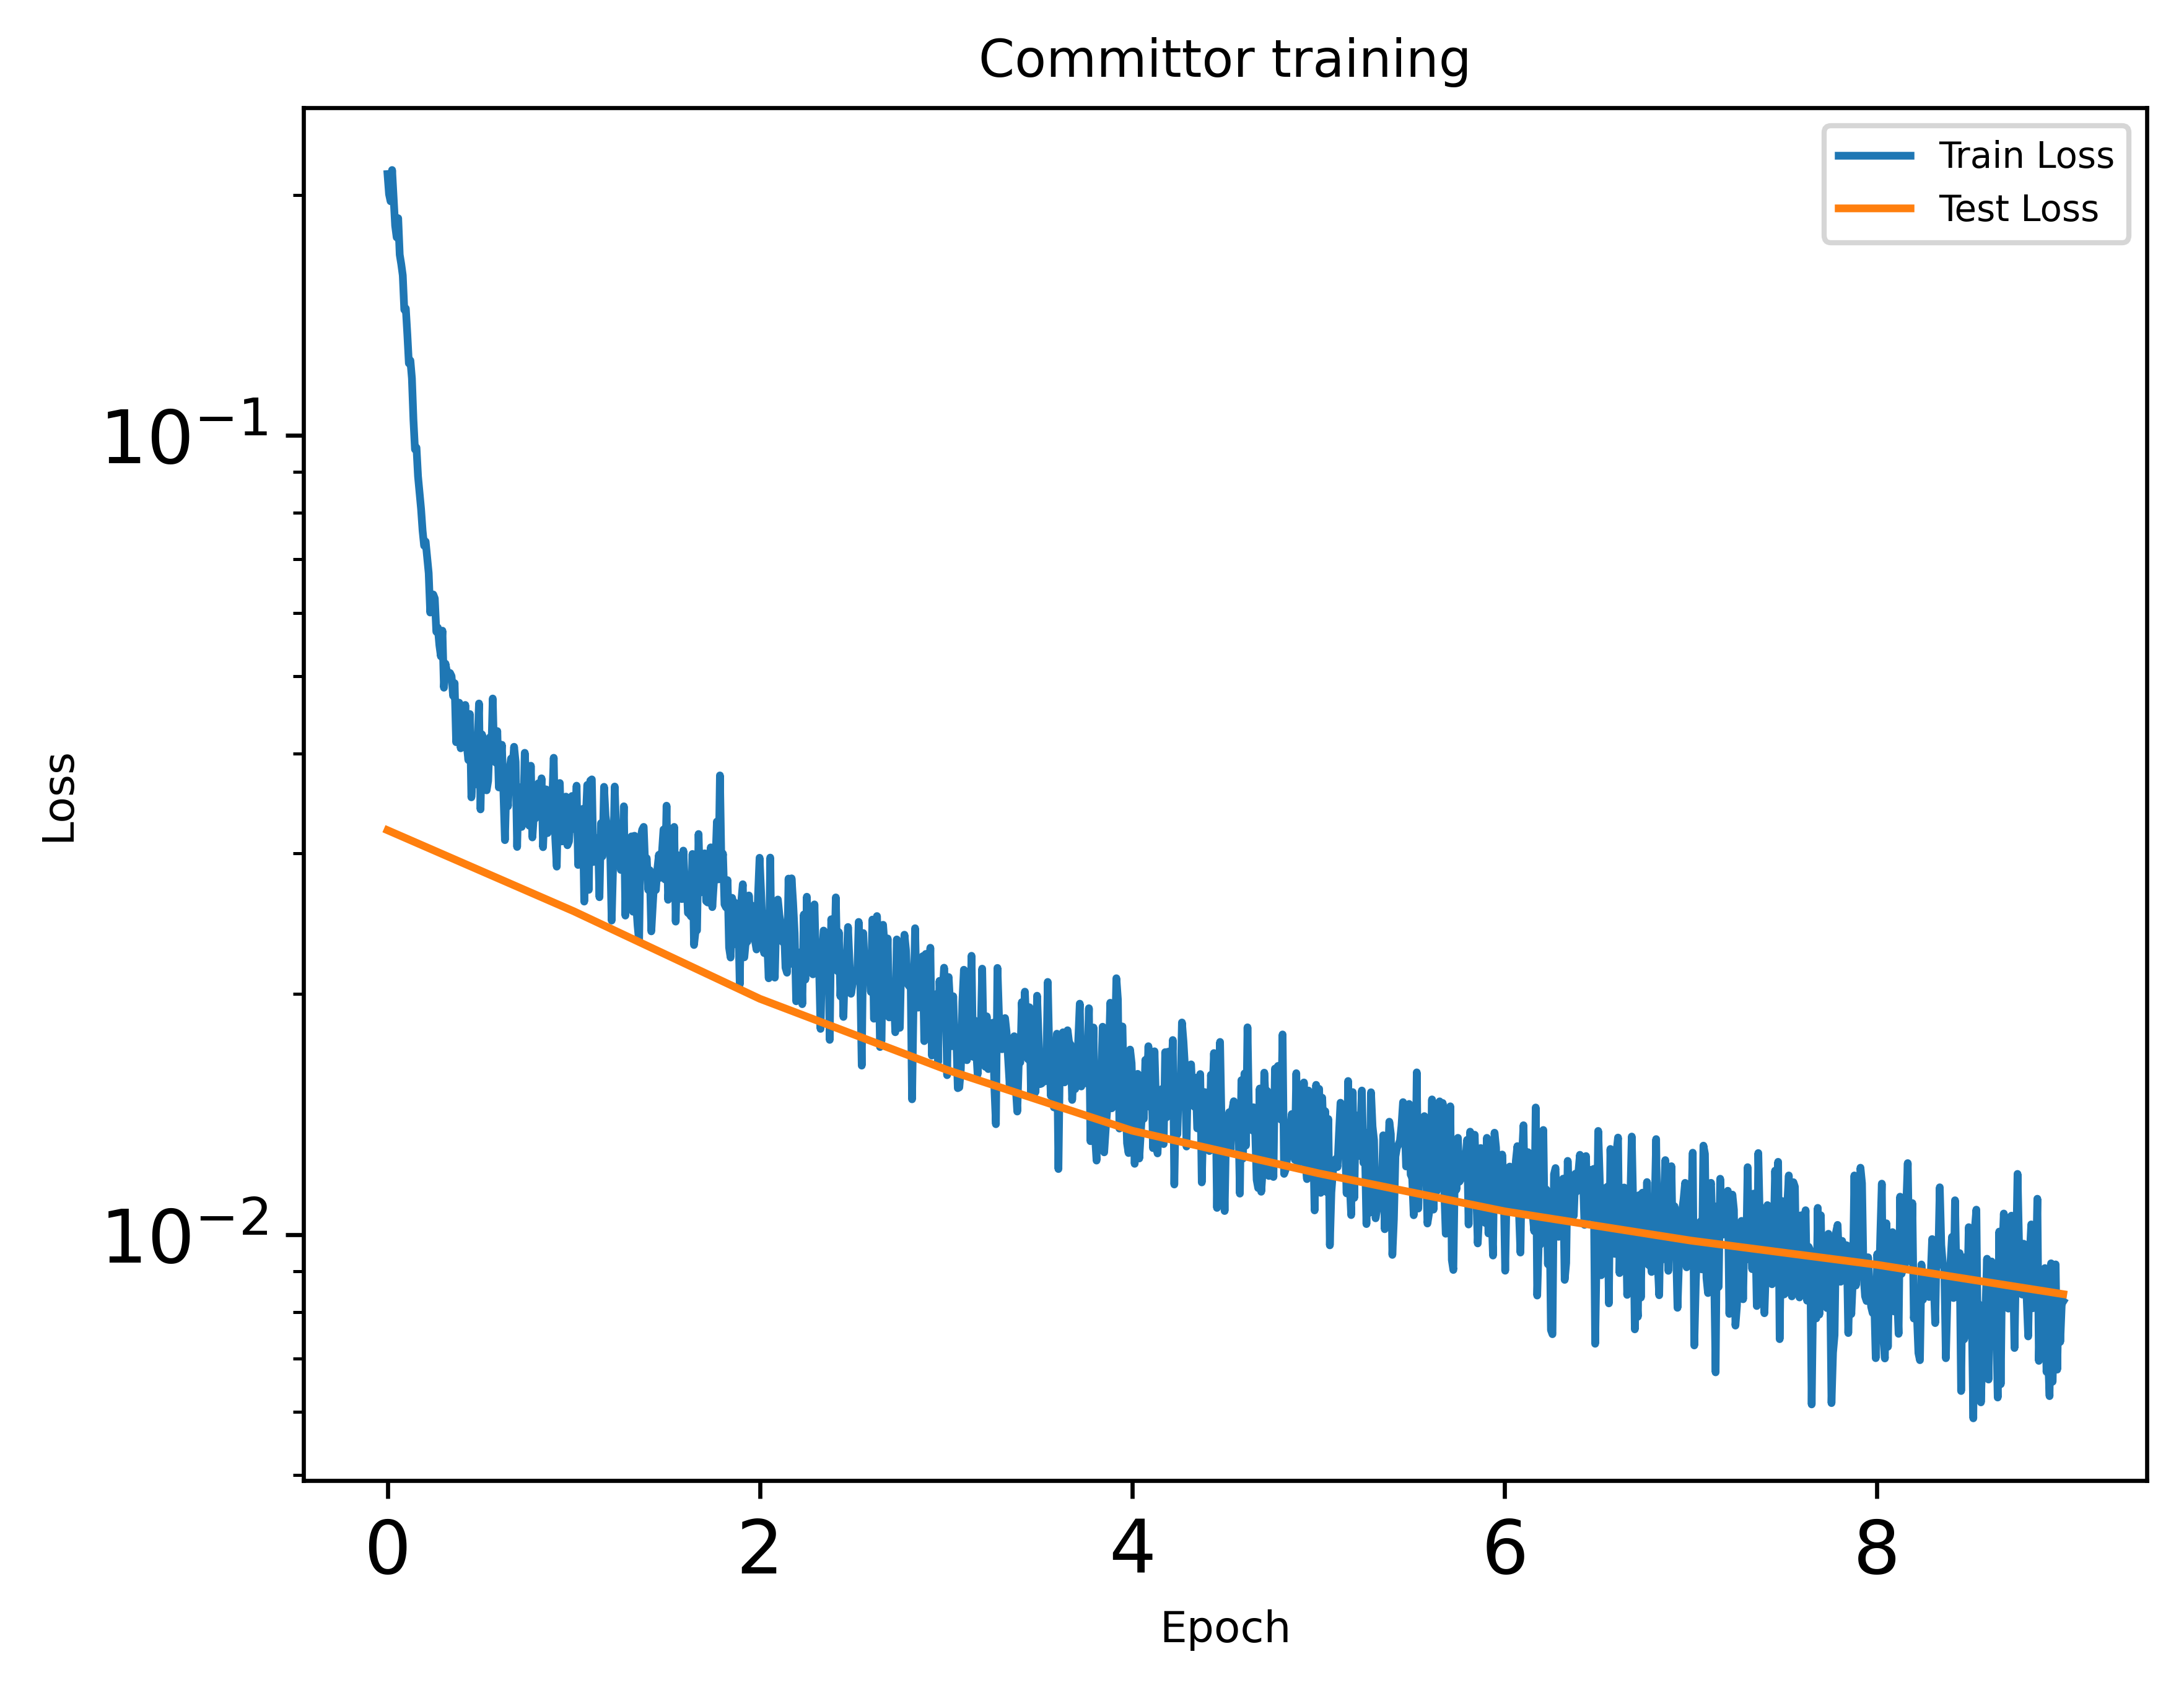

In [22]:
# Model training

model = GraphTransformer(num_beads = n_atoms, n_layers = 2, hidden_nf=64, conservative=True).to(device)
# model = SchNet(readout="mean").to(device)
# model = GCN(hidden_channels=64).to(device)


from models import CommittorNN
from utils import random_rotation


committor_model = CommittorNN(model)

# Train the model on the sampled molecules
batch_size = 1024
n_epochs = 10
max_data_size = 160000
data_augmentation = True
filter_transition = True
sl_loss_coeff = 1.0
grad_loss_coeff = 0.0
start_loss_coeff = 0.0
end_loss_coeff = 0.0

md_samples = md_samples[reweighting_factors > 0]
tic_cluster_assignments = tic_cluster_assignments[reweighting_factors > 0]
probs = probs[reweighting_factors > 0]
transformed_samples = transformed_samples[reweighting_factors > 0]
reweighting_factors = reweighting_factors[reweighting_factors > 0]


idxs = np.random.choice(md_samples.shape[0], min(max_data_size, md_samples.shape[0]), replace=False)
optimizer = torch.optim.Adam(committor_model.parameters(), lr=1e-5, weight_decay=0)
scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 200, \
                                                        total_steps = n_epochs * int(0.8 * len(idxs) / batch_size), \
                                                        lr_min=0.9, lr_max=1.0)
train_losses = []
test_losses = []

# split sampled_mol and cluster_assignments into train test sets
md_samples_keep = md_samples[idxs]
md_samples_keep = md_samples_keep - md_samples_keep.mean(1, keepdims=True)

tic_cluster_assignments_keep = tic_cluster_assignments[idxs]
reweighting_factors_keep = reweighting_factors[idxs]
probs_keep = probs[idxs]
transformed_samples_keep = transformed_samples[idxs]

x_train, x_test, tic_cluster_train, tic_cluster_test, weights_train, weights_test, probs_train, probs_test = train_test_split(md_samples_keep, tic_cluster_assignments_keep, reweighting_factors_keep, probs_keep, test_size=0.2)
trainset = torch.utils.data.TensorDataset(x_train, tic_cluster_train, weights_train, probs_train)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torch.utils.data.TensorDataset(x_test, tic_cluster_test, weights_test, probs_test)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

for e in range(n_epochs):
    committor_model.train()
    print(f"Epoch {e+1}")
    for x, tic_cluster, weights, prob in tqdm(train_dataloader):
        
        optimizer.zero_grad()
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        if data_augmentation:
            x = random_rotation(x)
        tic_cluster = tic_cluster.to(device)
        prob = prob.to(device)
        weights = weights.to(device)
        
        start_mask = tic_cluster == start
        end_mask = tic_cluster == end
        if filter_transition:
            transition_mask = torch.logical_and(~start_mask, ~end_mask)
        else:
            transition_mask = torch.ones_like(start_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        
        pred_prob = committor_model(x, h, t)
        if grad_loss_coeff > 0:
            grad_prob = torch.autograd.grad(
                outputs=pred_prob,  # [batch_size, ]
                inputs=x,  # [batch_size, n_nodes, 3]
                grad_outputs=torch.ones_like(pred_prob),
                retain_graph=True,  # Make sure the graph is not destroyed during training
                create_graph=True,  # Create graph for second derivative
                allow_unused=True,
                )[0]
        else:
            grad_prob = torch.zeros_like(x)
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0
        sl_loss = 0

        batch_weights = weights[transition_mask]
        batch_weights = batch_weights / batch_weights.sum()
        grad_loss = (batch_weights * grad_prob.square().sum((-2, -1))[transition_mask]).sum()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()
        
        sl_loss = (pred_prob - prob).square().mean()
        loss = loss = sl_loss_coeff*sl_loss + start_loss_coeff*start_boundary_loss + end_loss_coeff*end_boundary_loss + grad_loss_coeff*grad_loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.detach().unsqueeze(-1) if grad_loss_coeff == 0 else KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) *grad_loss.detach().unsqueeze(-1))
        

    # Test the model on the test set
    committor_model.eval()
    tls = []
    for x, tic_cluster, weights, prob in test_dataloader:
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        tic_cluster = tic_cluster.to(device)
        prob = prob.to(device)
        weights = weights.to(device)
        start_mask = tic_cluster == start
        end_mask = tic_cluster == end
        if filter_transition:
            
            transition_mask = torch.logical_and(~start_mask, ~end_mask)
        else:
            transition_mask = torch.ones_like(start_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        if grad_loss_coeff > 0:
            grad_prob = torch.autograd.grad(
                outputs=pred_prob,  # [batch_size, ]
                inputs=x,  # [batch_size, n_nodes, 3]
                grad_outputs=torch.ones_like(pred_prob),
                retain_graph=True,  # Make sure the graph is not destroyed during training
                create_graph=True,  # Create graph for second derivative
                allow_unused=True,
                )[0]
        else:
            grad_prob = torch.zeros_like(x)
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        batch_weights = weights[transition_mask]
        batch_weights = batch_weights / batch_weights.sum()

        grad_loss = (batch_weights * grad_prob.square().sum((-2, -1))[transition_mask]).sum()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()

        sl_loss = (pred_prob - prob).square().mean()

        loss = loss = sl_loss_coeff*sl_loss + start_loss_coeff*start_boundary_loss + end_loss_coeff*end_boundary_loss + grad_loss_coeff*grad_loss
        tls.append(loss.detach().unsqueeze(-1) if grad_loss_coeff == 0 else KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses) *grad_loss.detach().unsqueeze(-1))
    
    test_loss = torch.cat(tls).sum(0) / len(tls)
    test_losses.append(test_loss.unsqueeze(-1))


train_losses = torch.cat(train_losses).cpu().numpy()
test_losses = torch.cat(test_losses).cpu().numpy()

plot_losses(train_losses, test_losses, "Committor training", true_rate=gt_rates[protein_name] if grad_loss_coeff > 0 else None)

# Save the model
torch.save(committor_model, f"./saved_models/{protein_name}/committor-rate-model-{start}_{end}.pt")


100%|██████████| 28/28 [00:01<00:00, 19.24it/s]


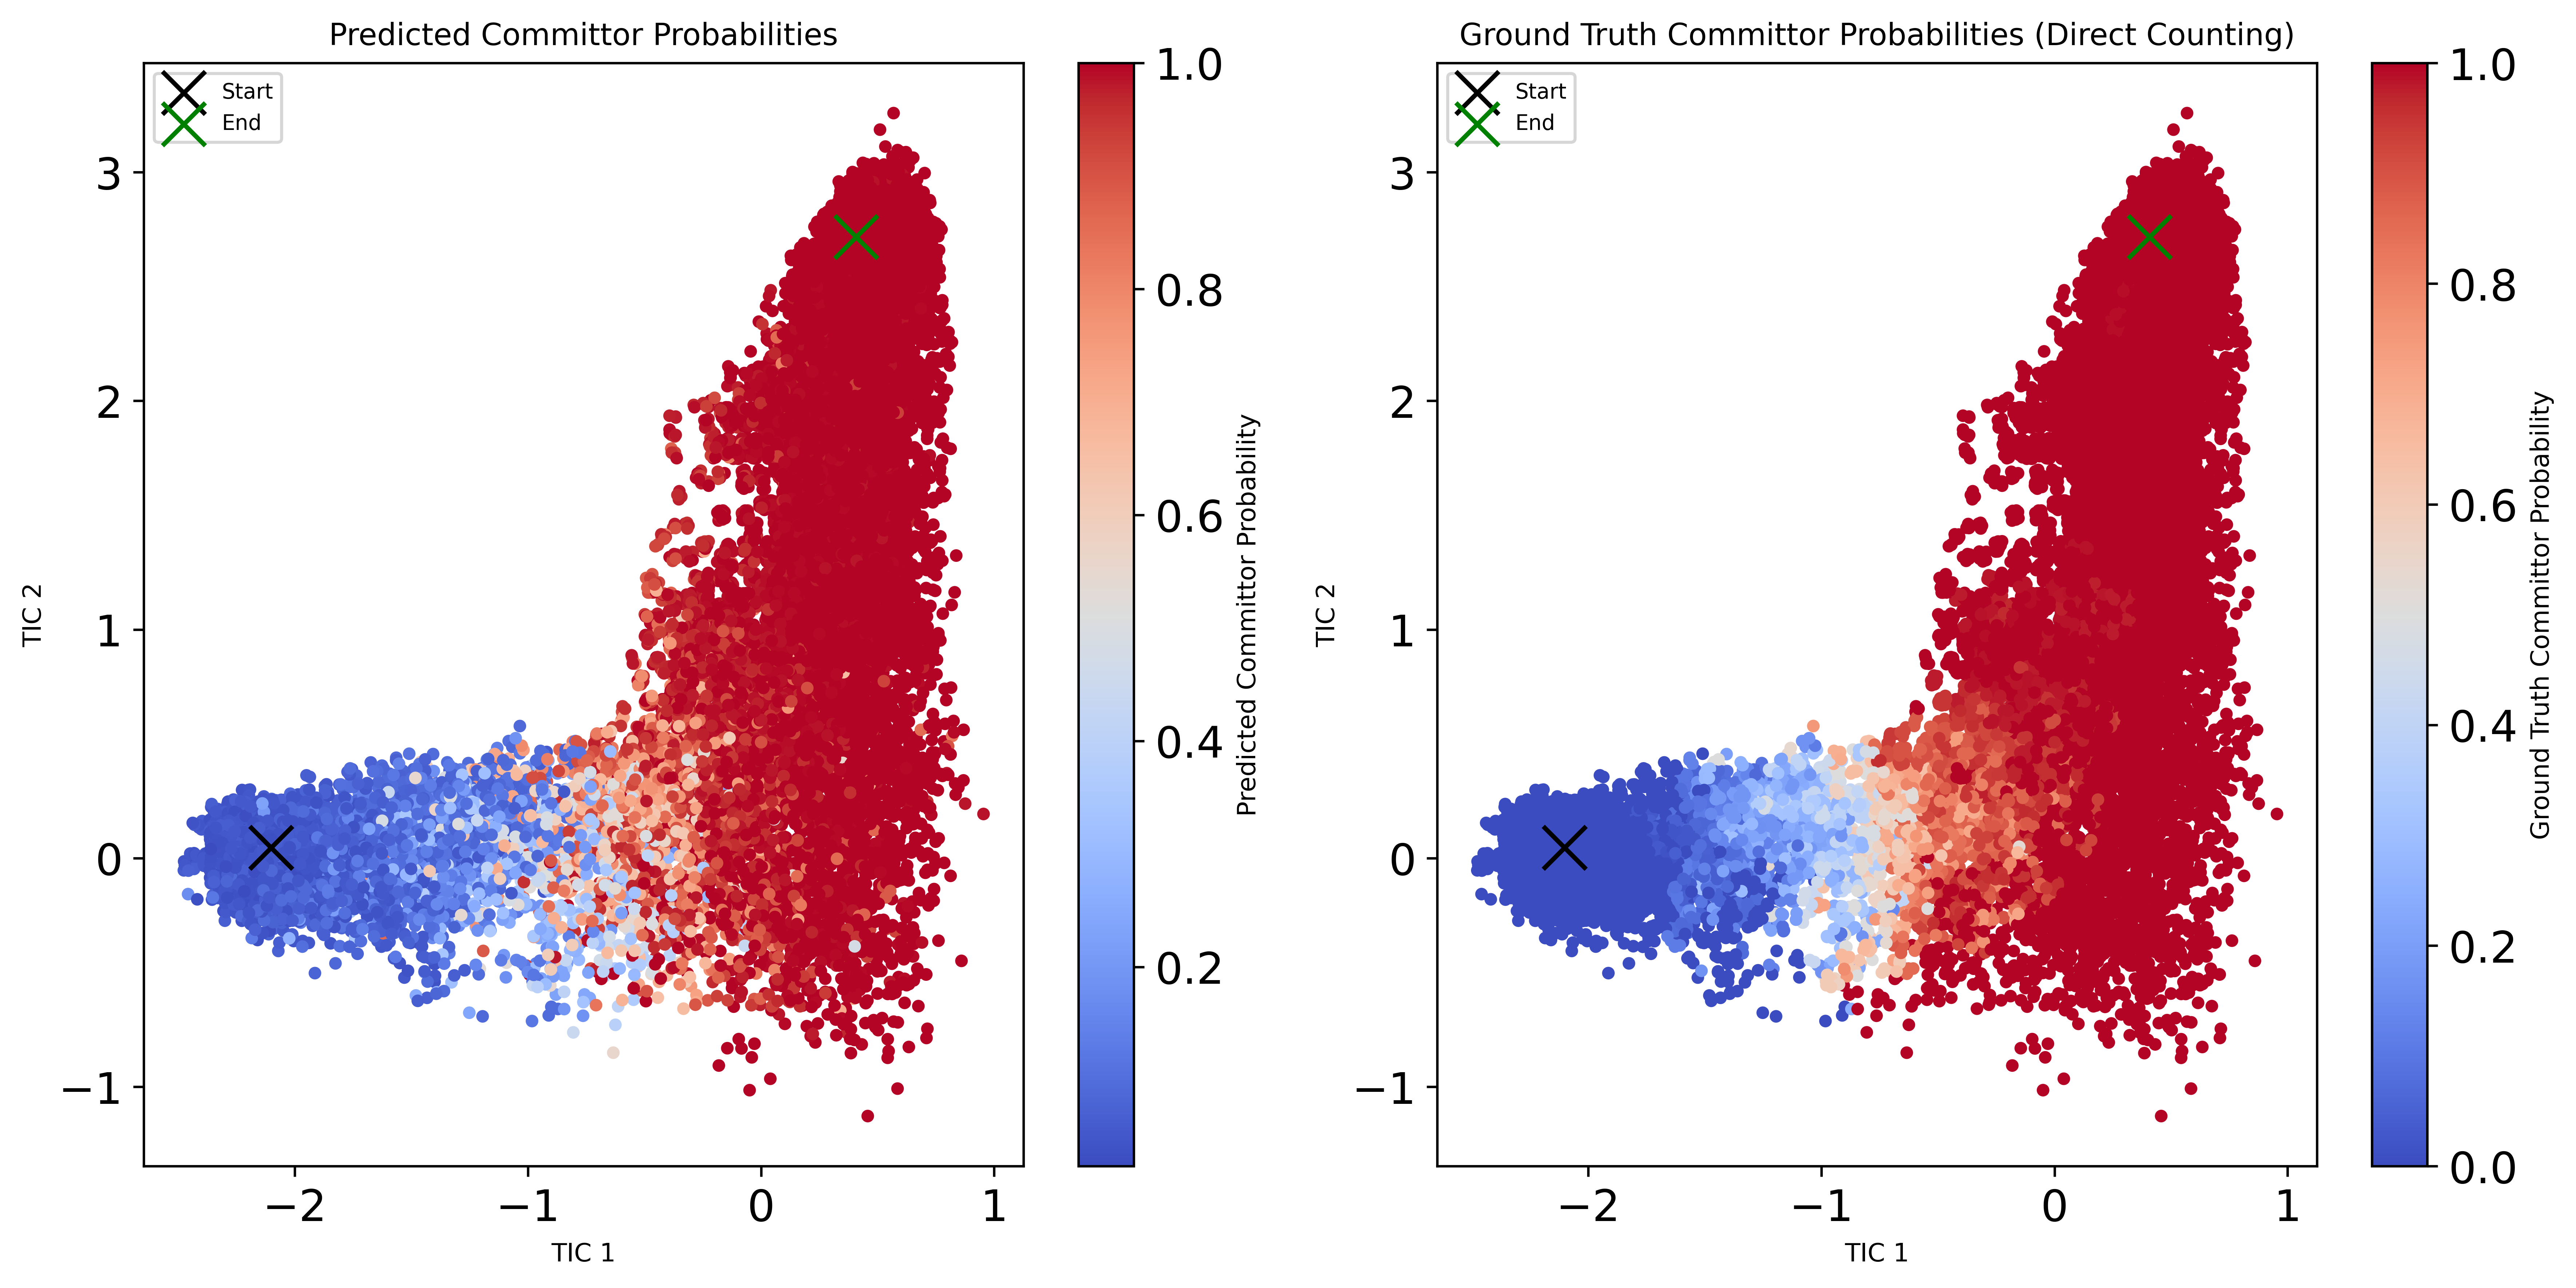

In [23]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Evaluate the committor model and get predicted probabilities
committor_model.eval()

committor_probs = []
for x in tqdm(x_test.split(batch_size)):
    x = x.to(device).requires_grad_(True)
    x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
    h = torch.eye(n_atoms).to(device)
    t = torch.zeros((x.shape[0], )).to(device)
    pred_prob = committor_model(x, h, t)
    committor_probs.append(pred_prob.detach())

committor_probs = torch.cat(committor_probs).cpu().detach().numpy()

# Get TICA for the ground truth data
sample_tic_features = tic_evaluator.get_tic_features(
        x_test, tic_evaluator.folded
    )
test_transformed_samples = tic_evaluator.tica(sample_tic_features)

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the predicted committor probabilities
scatter1 = axs[0].scatter(test_transformed_samples[:, 0], test_transformed_samples[:, 1], c=committor_probs, cmap='coolwarm', s=10)
axs[0].set_title('Predicted Committor Probabilities')
axs[0].set_xlabel('TIC 1')
axs[0].set_ylabel('TIC 2')
axs[0].scatter(tic_cluster_coords[start, 0], tic_cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[0].scatter(tic_cluster_coords[end, 0], tic_cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[0].legend()
plt.colorbar(scatter1, ax=axs[0], label='Predicted Committor Probability')

# Plot the ground truth committor probabilities
scatter2 = axs[1].scatter(test_transformed_samples[:, 0], test_transformed_samples[:, 1], c=probs_test, cmap='coolwarm', s=10)
axs[1].set_title('Ground Truth Committor Probabilities (Direct Counting)')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')
axs[1].scatter(tic_cluster_coords[start, 0], tic_cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[1].scatter(tic_cluster_coords[end, 0], tic_cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[1].legend()
plt.colorbar(scatter2, ax=axs[1], label='Ground Truth Committor Probability')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [24]:
from ase import units
def compute_rates(samples, weights, committor_model):
    """
    samples: torch.tensor of shape [N_samples, 2]
    weights: torch.tensor of shape [N_samples, 1]
    committor_model: NN trained to predict committor probabilities
    """
    weights = weights / weights.sum()
    # weights = 1 / len(weights) * torch.ones_like(weights)
    # Loop over samples and compute grad of model-predicted committors
    committor_model.eval()
    committor_probs = []
    grad_committor_prob_norms = []
    for x in tqdm(samples.split(int(batch_size))):
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        x = x.to(torch.float32)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)

        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size]
            inputs=x,  # [batch_size, N_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=False,  # Make sure the graph is not destroyed during training
            create_graph=False,  # Create graph for second derivative
            allow_unused=True,
            )[0].detach()
        grad_committor_prob_norms.append(grad_prob.reshape(x.shape[0], -1).norm(dim=-1)**2)
    
    grad_committor_prob_norms = torch.cat(grad_committor_prob_norms)
    
    # Compute a weighted average of the grad of the committor (this is the rate)
    ensemble_average = (weights * grad_committor_prob_norms).sum()

    # Sort values by grad_committor_prob_norms
    # sorted_indices = torch.argsort(grad_committor_prob_norms)
    # sorted_norms = grad_committor_prob_norms[sorted_indices]
    # sorted_weights = weights[sorted_indices]

    # # Compute cumulative sum of weights
    # cumulative_weights = torch.cumsum(sorted_weights, 0)

    # # Find the index where cumulative weight exceeds 0.5 (median position)
    # median_index = torch.searchsorted(cumulative_weights, 0.5)

    # # Weighted median
    # ensemble_average = sorted_norms[median_index]
    # D = KB / (norm_stds[Molecules[protein_name.upper()]]**2) * temp_data / (friction * masses)
    D = 1
    rate_ps = D * ensemble_average
    rate_ns = rate_ps * 1e3
    N_eff = (-weights * torch.log(weights)).sum().exp()  # effective sample size

    print(f"Rate (ns^-1): {rate_ns.item()}, Ensemble Average: {ensemble_average}, Effective sample size: {N_eff} out of {len(samples)} samples")
    return rate_ns, ensemble_average, N_eff, grad_committor_prob_norms

reweighting_factors_keep = reweighting_factors[idxs]
rate, ensemble_average, N_eff, grad_committor_prob_norms = compute_rates(torch.tensor(md_samples_keep), torch.tensor(reweighting_factors_keep).to(device), committor_model)

/tmp/ipykernel_3698186/1729822187.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rate, ensemble_average, N_eff, grad_committor_prob_norms = compute_rates(torch.tensor(md_samples_keep), torch.tensor(reweighting_factors_keep).to(device), committor_model)
100%|██████████| 137/137 [00:15<00:00,  9.12it/s]

Rate (ns^-1): 49.87356917306895, Ensemble Average: 0.04987356917306895, Effective sample size: 14444.808860292713 out of 140146 samples


In [25]:
reweighting_factors_keep.min(), reweighting_factors_keep.max()

(tensor(0.0071, dtype=torch.float64), tensor(669.2023, dtype=torch.float64))

([<matplotlib.axis.XTick at 0x7f453f337590>,
 [Text(1e-20, 0, '$\\mathdefault{10^{-20}}$'),
  Text(1e-15, 0, '$\\mathdefault{10^{-15}}$'),
  Text(1e-10, 0, '$\\mathdefault{10^{-10}}$'),
  Text(1e-05, 0, '$\\mathdefault{10^{-5}}$'),
  Text(0.0001, 0, '$\\mathdefault{10^{-4}}$'),
  Text(0.001, 0, '$\\mathdefault{10^{-3}}$'),
  Text(0.01, 0, '$\\mathdefault{10^{-2}}$'),
  Text(0.1, 0, '$\\mathdefault{10^{-1}}$'),
  Text(1.0, 0, '$\\mathdefault{10^{0}}$')])

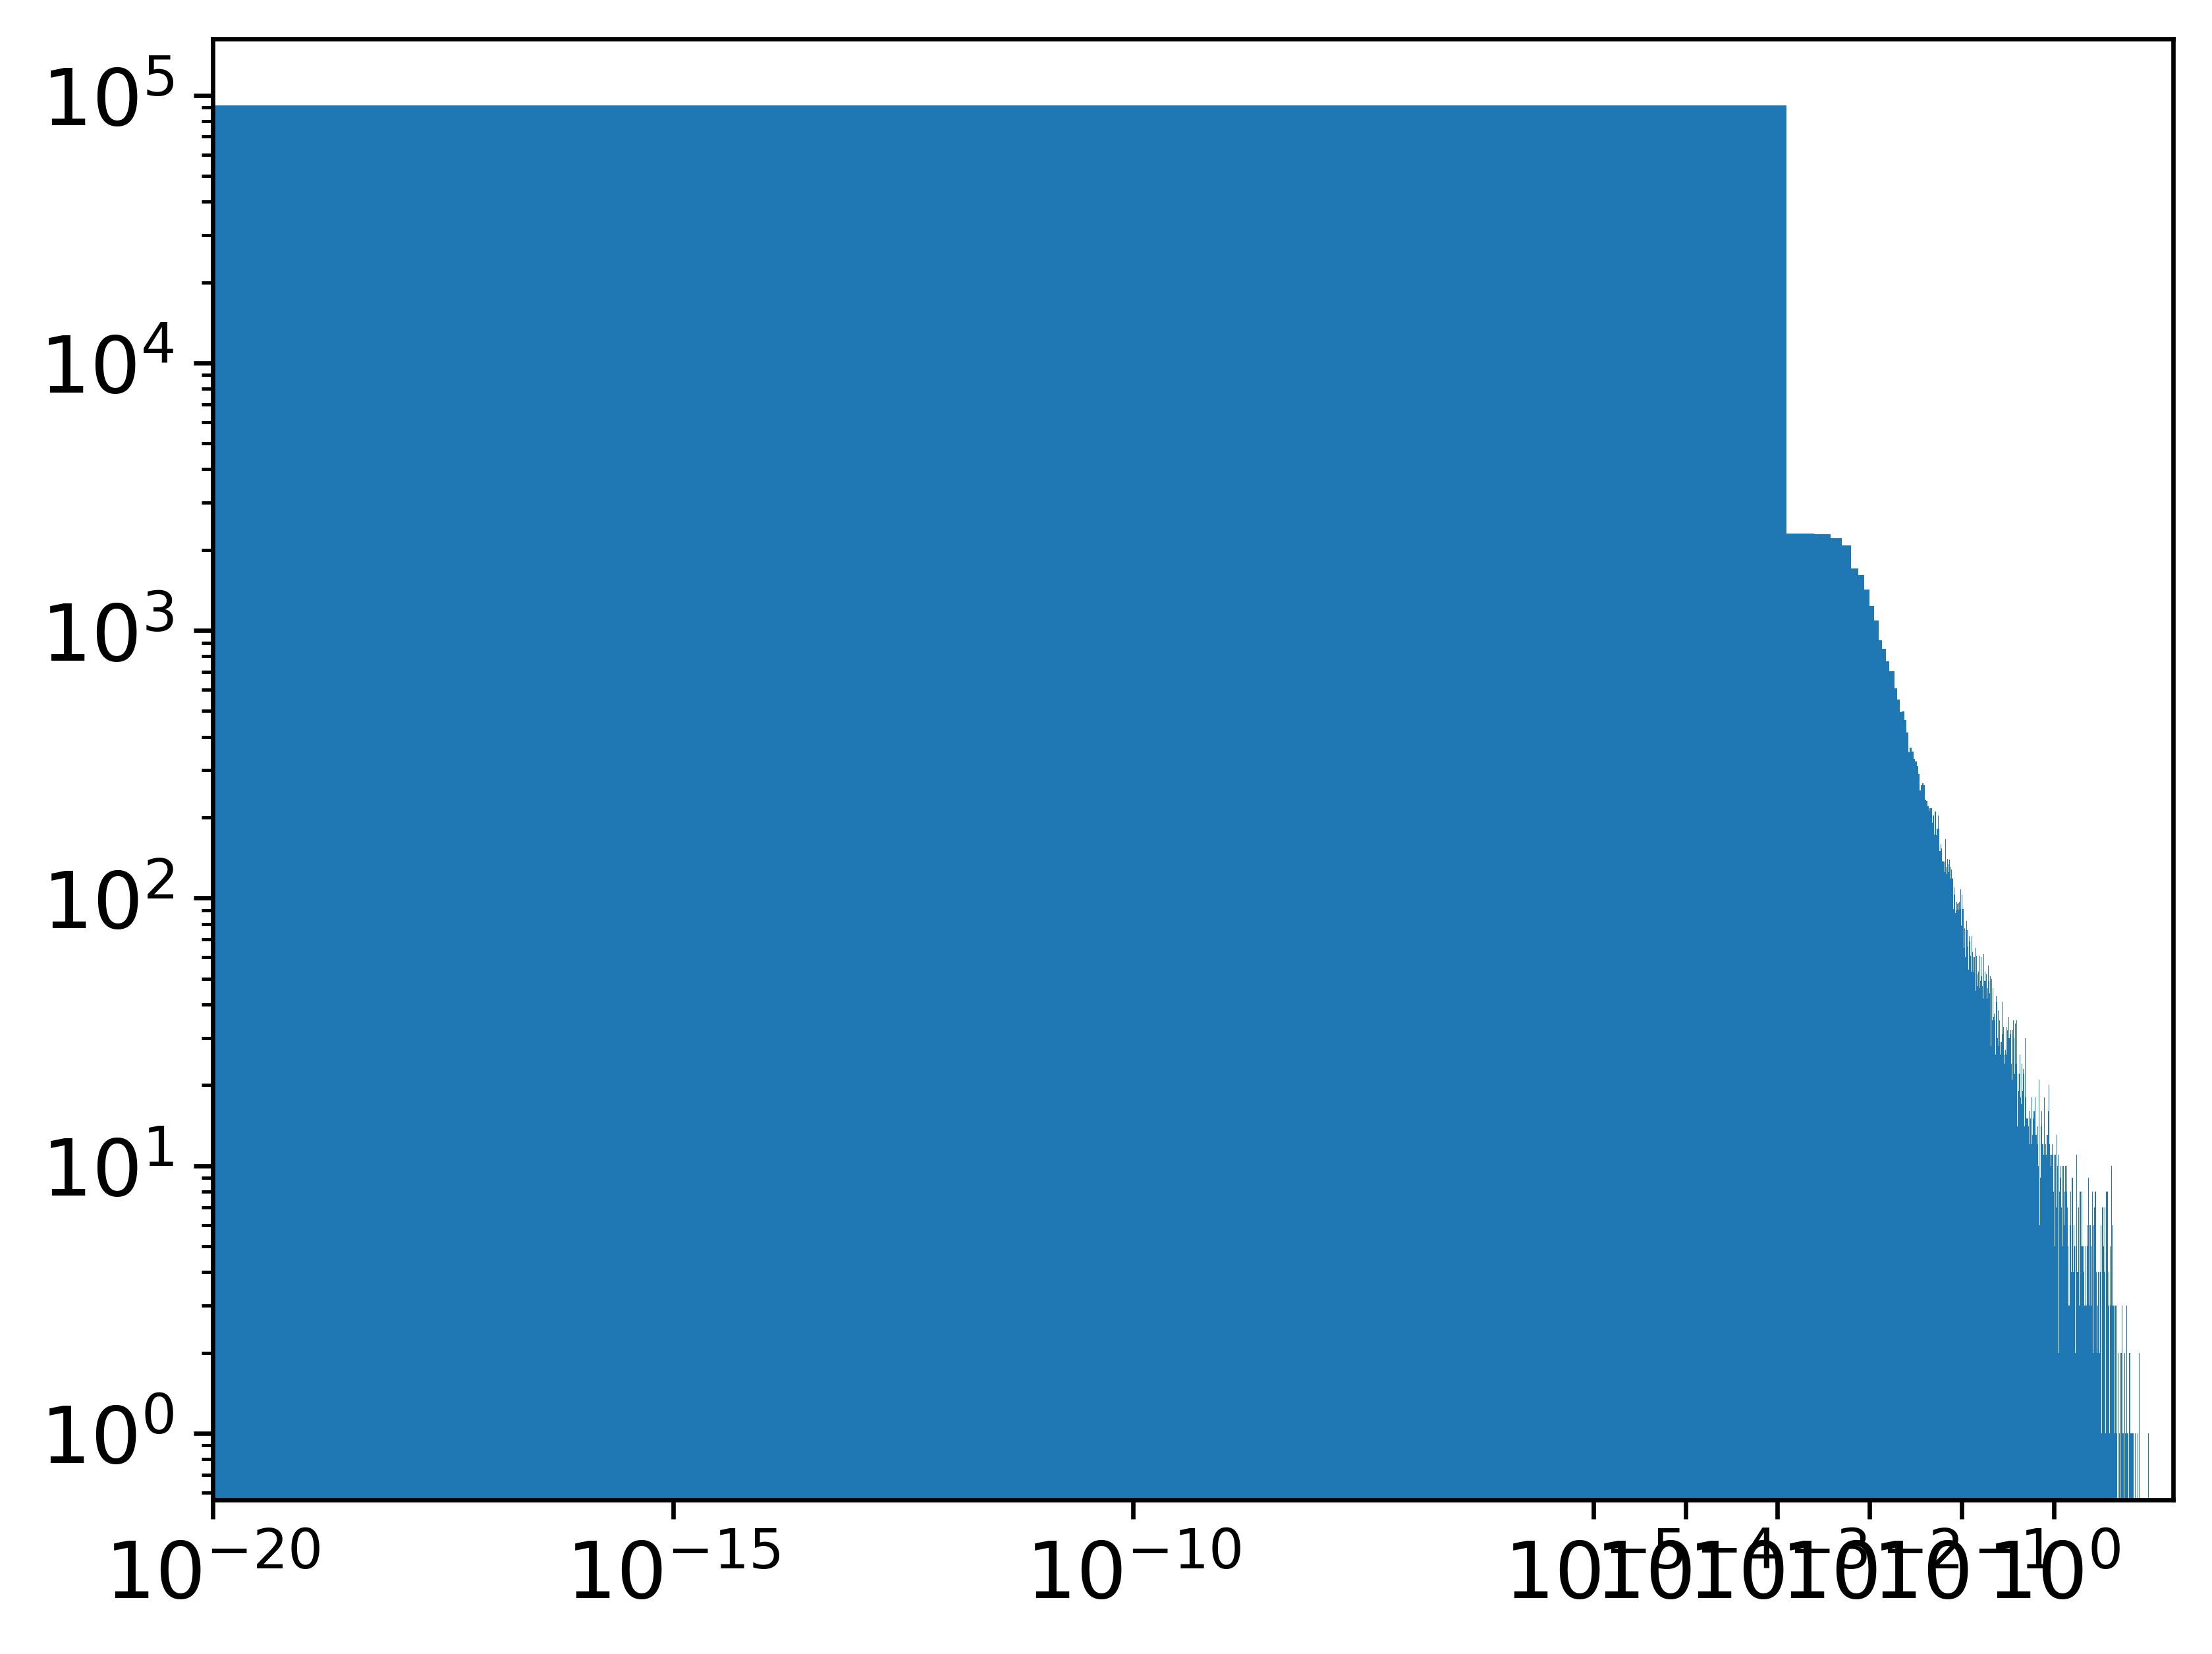

In [46]:
plt.hist(grad_committor_prob_norms.cpu().numpy(), bins=10000)
plt.xscale('log')
plt.yscale('log')
plt.xticks([1e-20, 1e-15, 1e-10, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])

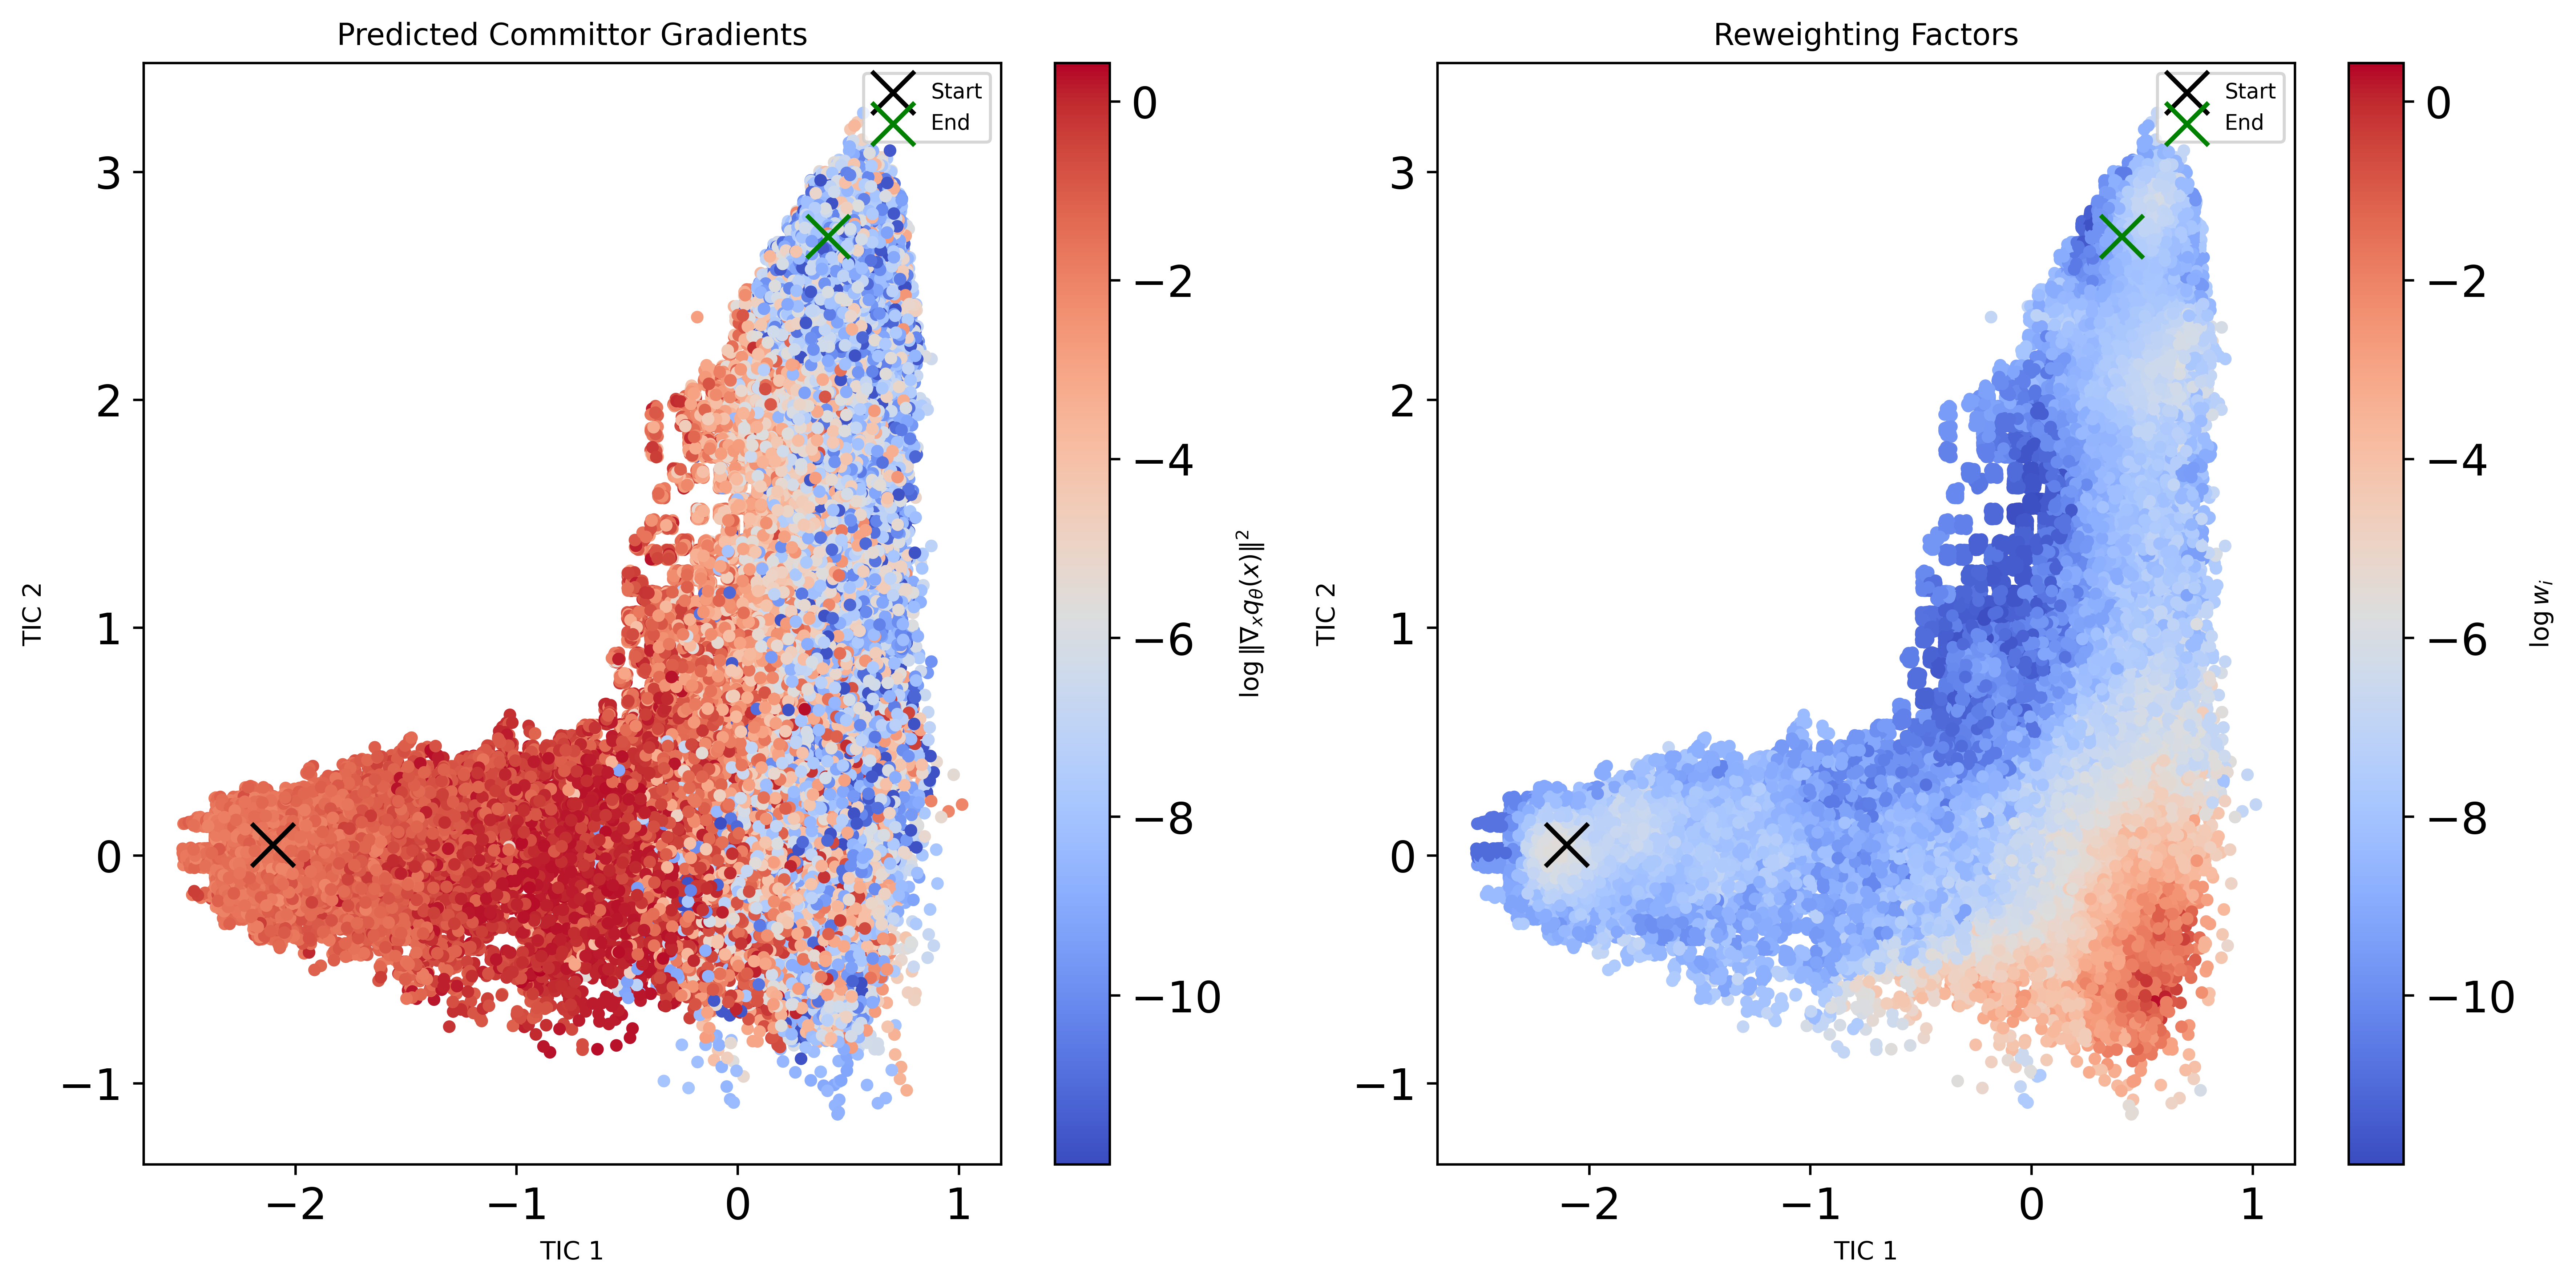

In [26]:

# Import necessary libraries
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Visualize the distribution of predicted committor norms
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the predicted committor grad norms
scatter1 = axs[0].scatter(transformed_samples_keep[:, 0], transformed_samples_keep[:, 1], c=grad_committor_prob_norms.log10().cpu(), cmap='coolwarm', s=10)
axs[0].set_title('Predicted Committor Gradients')
axs[0].set_xlabel('TIC 1')
axs[0].set_ylabel('TIC 2')
axs[0].scatter(tic_cluster_coords[start, 0], tic_cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[0].scatter(tic_cluster_coords[end, 0], tic_cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[0].legend()
plt.colorbar(scatter1, ax=axs[0], label=r'$\log \|\nabla_x q_\theta(x)\|^2$')

# Plot the predicted committor grad norms
reweighting_factors_keep = reweighting_factors[idxs]
reweighting_factors_keep /= reweighting_factors_keep.sum()
scatter2 = axs[1].scatter(transformed_samples_keep[:, 0], transformed_samples_keep[:, 1], c=reweighting_factors_keep.log10().cpu(), cmap='coolwarm', s=10)
axs[1].set_title('Reweighting Factors')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')
axs[1].scatter(tic_cluster_coords[start, 0], tic_cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[1].scatter(tic_cluster_coords[end, 0], tic_cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[1].legend()
plt.colorbar(scatter1, ax=axs[1], label=r'$\log w_i$')

plt.tight_layout()
plt.show()


tensor(-3.0761, dtype=torch.float64)